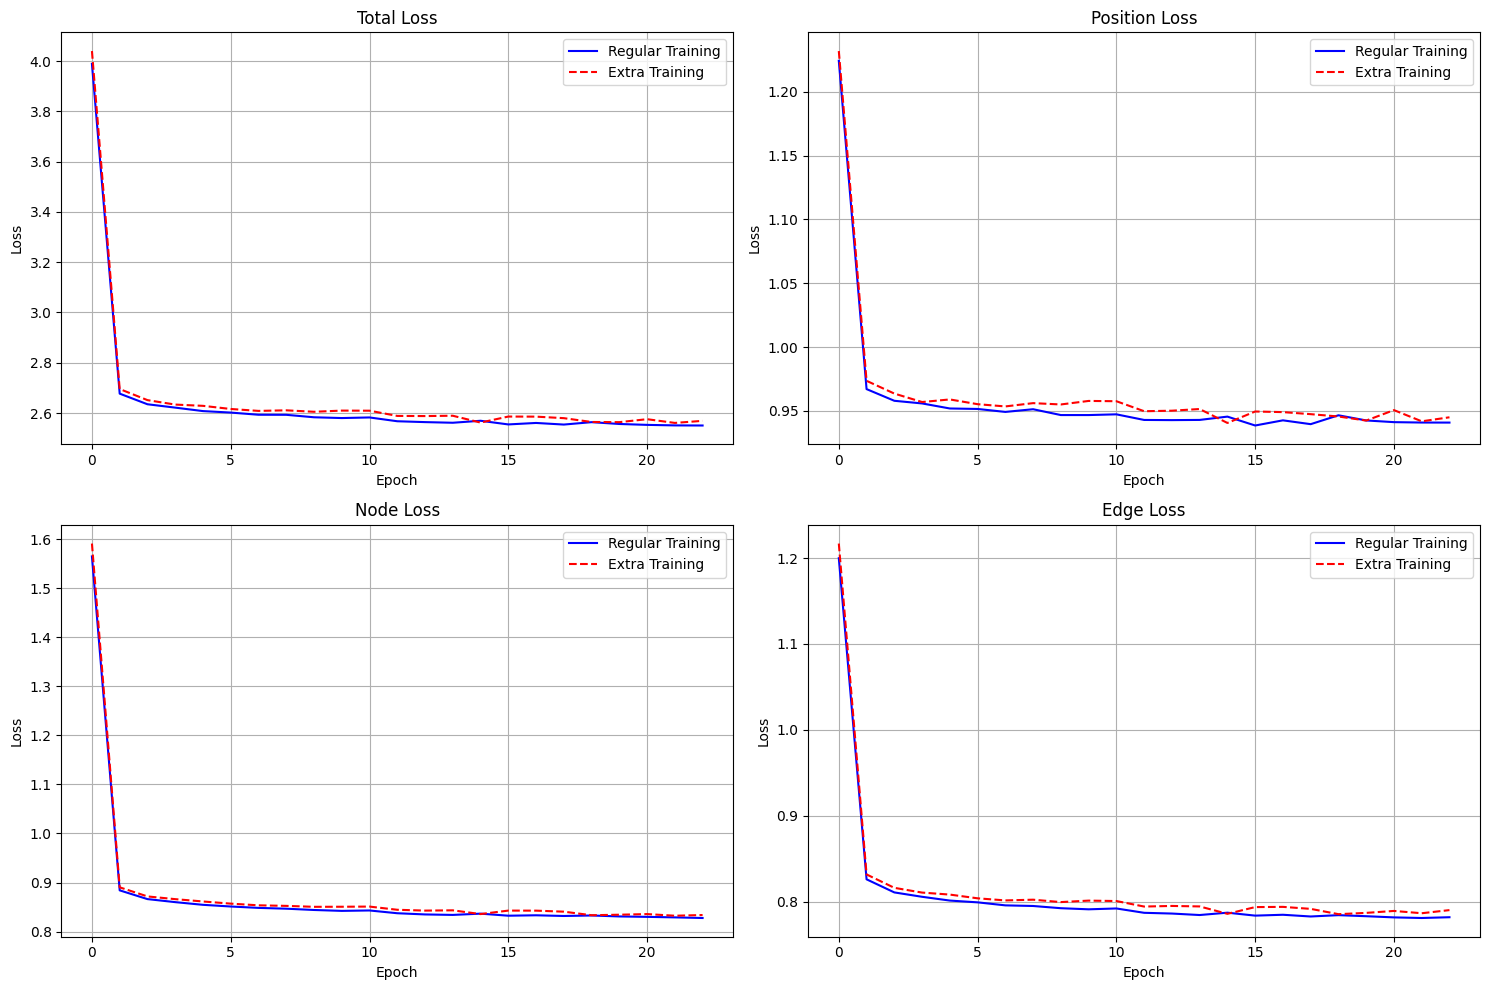

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('/home/chengxi/data/work/test/comp2404/PMT/PMT_250421/peptide2mol/logs_retrain/train_Moldiff_test/runs/2025-04-29_03-57-20/cases_losses.txt')

# Group by epoch and is_extra_training, calculate mean for each loss type
grouped = df.groupby(['epoch', 'is_extra_training'])[['total_loss', 'loss_pos', 'loss_node', 'loss_edge']].mean().reset_index()

# Separate data for regular and extra training
regular = grouped[grouped['is_extra_training'] == False]
extra = grouped[grouped['is_extra_training'] == True]

# Create a figure with subplots
plt.figure(figsize=(15, 10))

# Plot each loss type
loss_types = ['total_loss', 'loss_pos', 'loss_node', 'loss_edge']
titles = ['Total Loss', 'Position Loss', 'Node Loss', 'Edge Loss']

for i, (loss_type, title) in enumerate(zip(loss_types, titles), 1):
    plt.subplot(2, 2, i)
    
    # Plot regular training
    plt.plot(regular['epoch'], regular[loss_type], 'b-', label='Regular Training')
    
    # Plot extra training if exists
    if not extra.empty:
        plt.plot(extra['epoch'], extra[loss_type], 'r--', label='Extra Training')
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.savefig('loss_plots.png')

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('/home/chengxi/data/work/test/comp2404/PMT/PMT_250421/peptide2mol/logs_retrain/train_Moldiff_test/runs/2025-04-29_03-57-20/cases_losses.txt')

# Categorize items based on name prefixes
def categorize_name(name):
    if name.startswith('PBmol'):
        return 'PBmol'
    elif name.startswith('cpep_AF'):
        return 'cpep_AF'
    elif name.startswith('pep'):
        return 'pep'
    elif name.startswith('mol') and '_poc' in name:
        return 'mol_poc'
    else:
        return 'GEOM molecules'

df['category'] = df['name'].apply(categorize_name)

# Group by epoch, is_extra_training, and category, calculate mean for each loss type
grouped = df.groupby(['epoch', 'is_extra_training', 'category'])[['total_loss', 'loss_pos', 'loss_node', 'loss_edge']].mean().reset_index()

# Create a figure for each category
categories = df['category'].unique()
loss_types = ['total_loss', 'loss_pos', 'loss_node', 'loss_edge']
titles = ['Total Loss', 'Position Loss', 'Node Loss', 'Edge Loss']


    # plt.close()

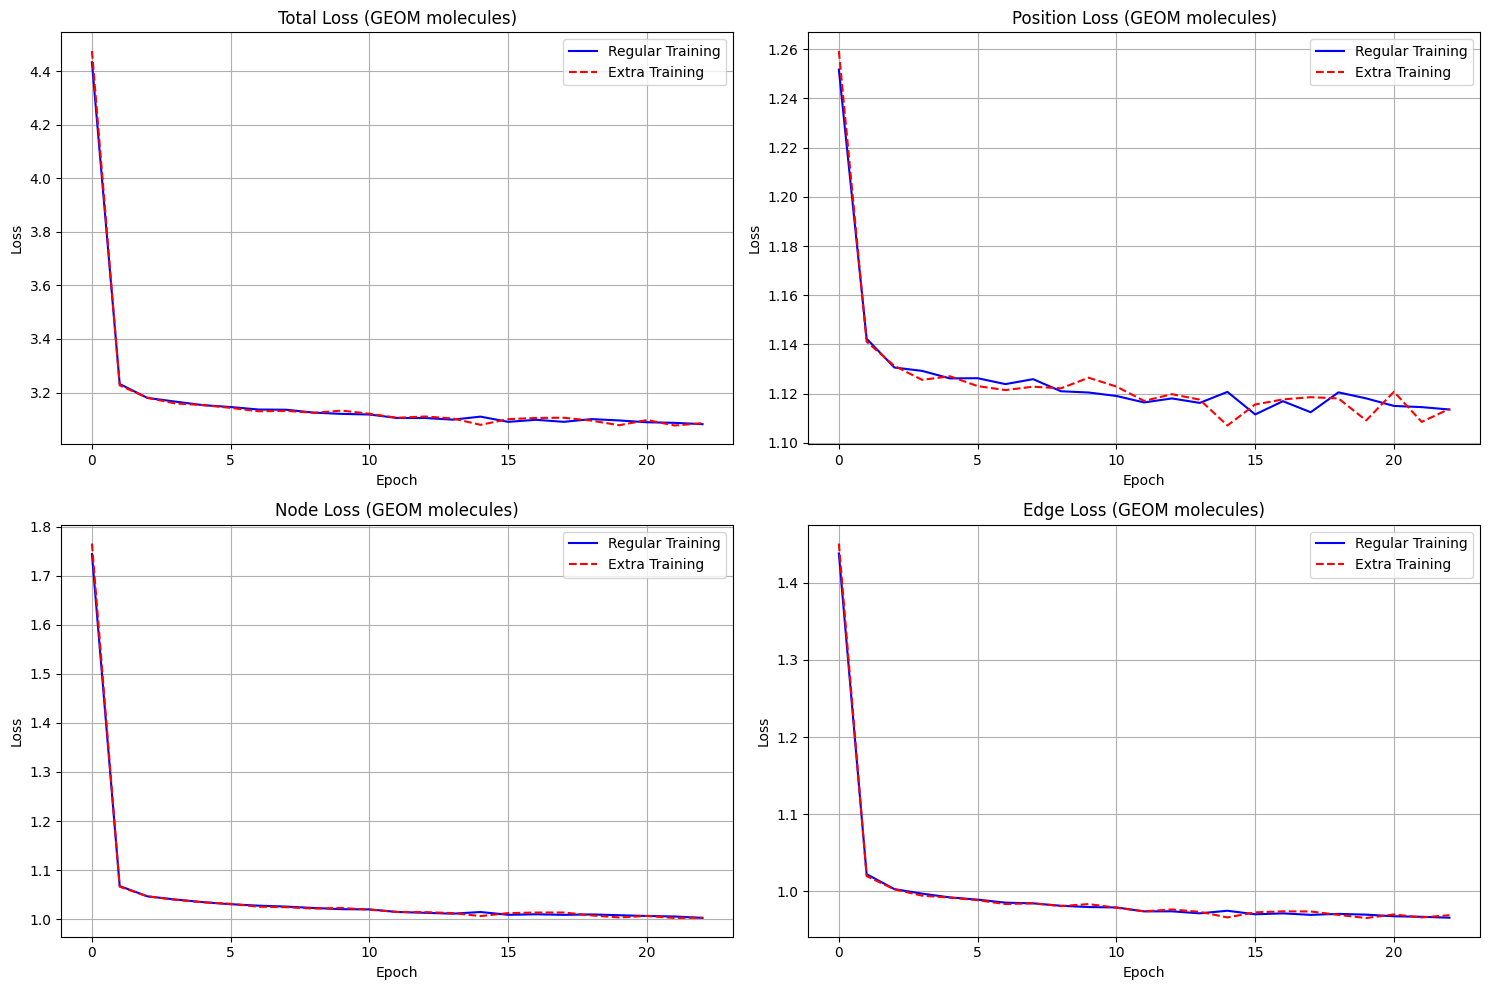

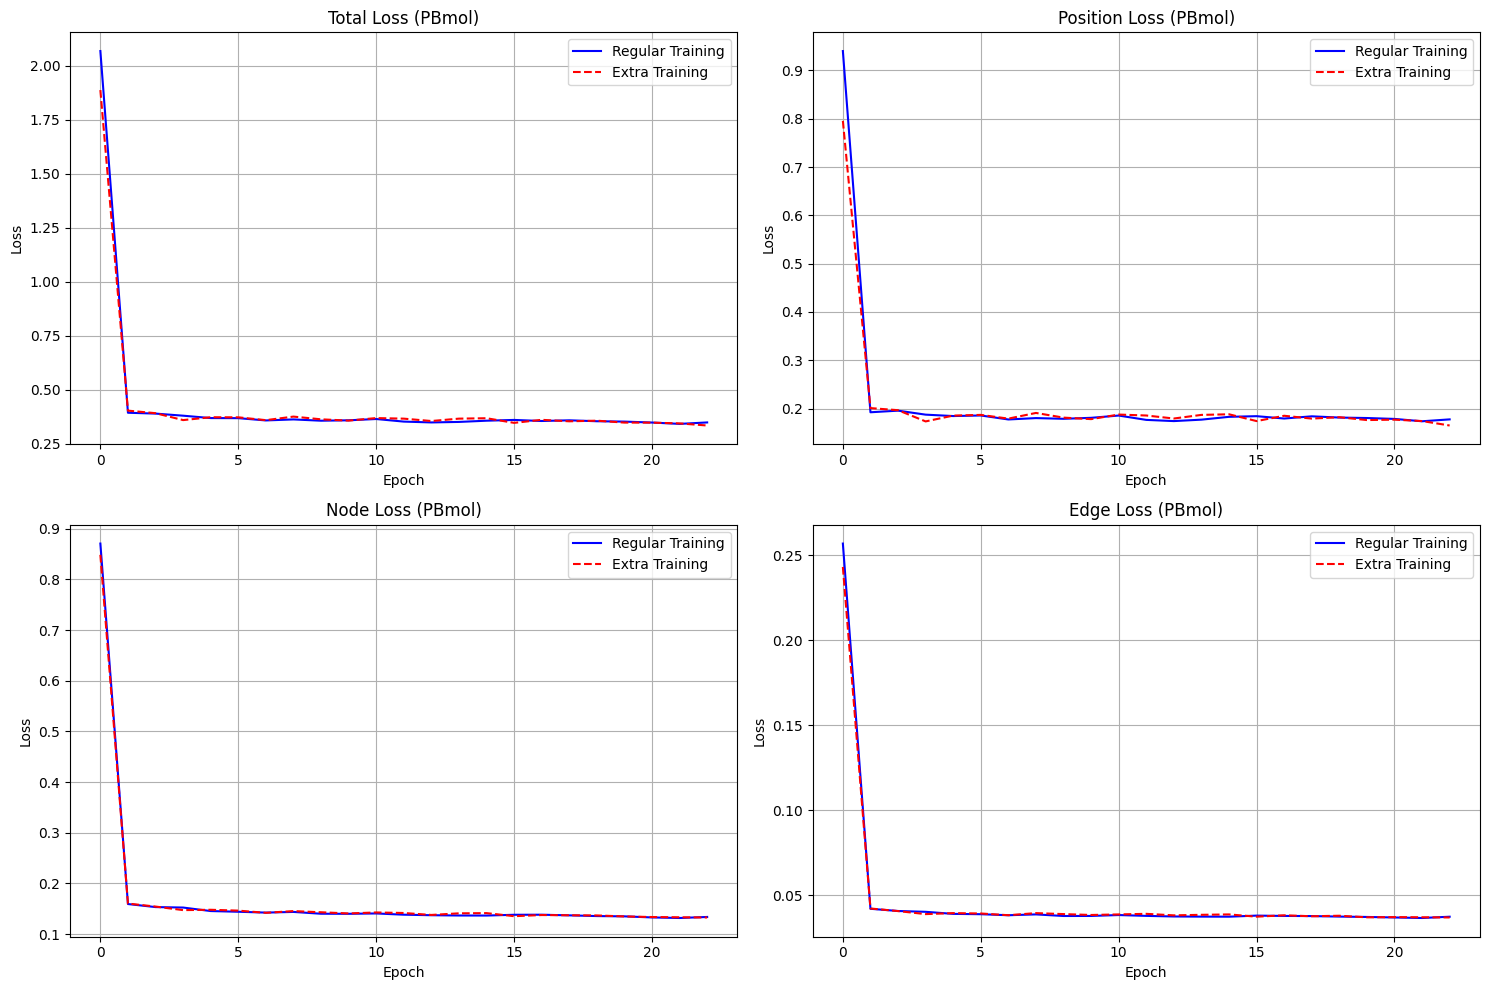

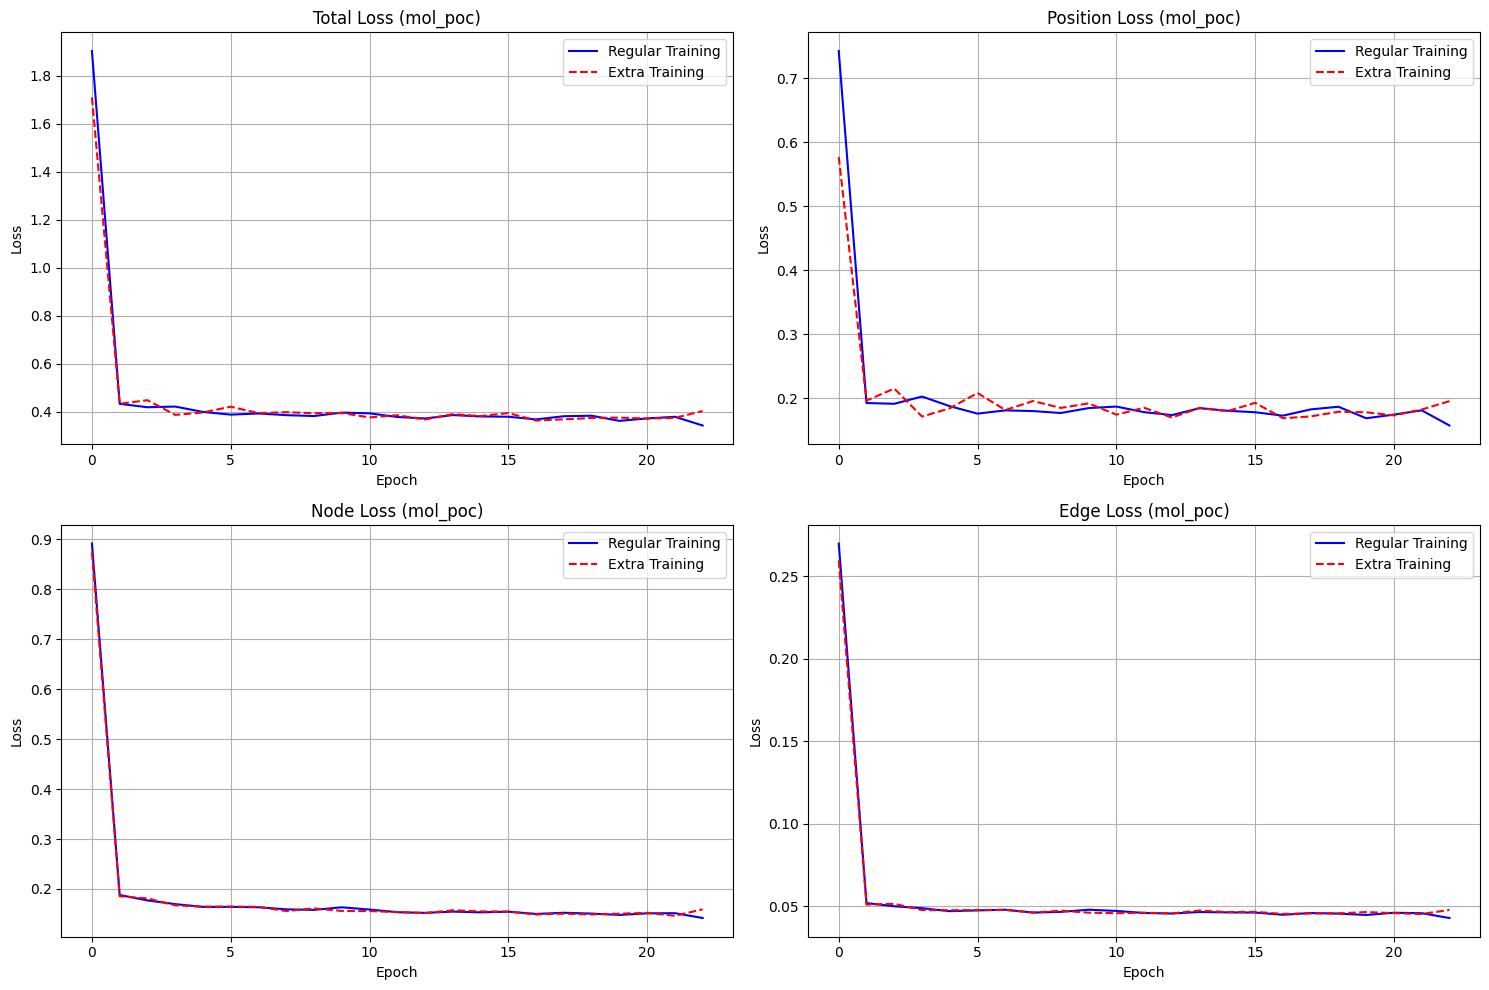

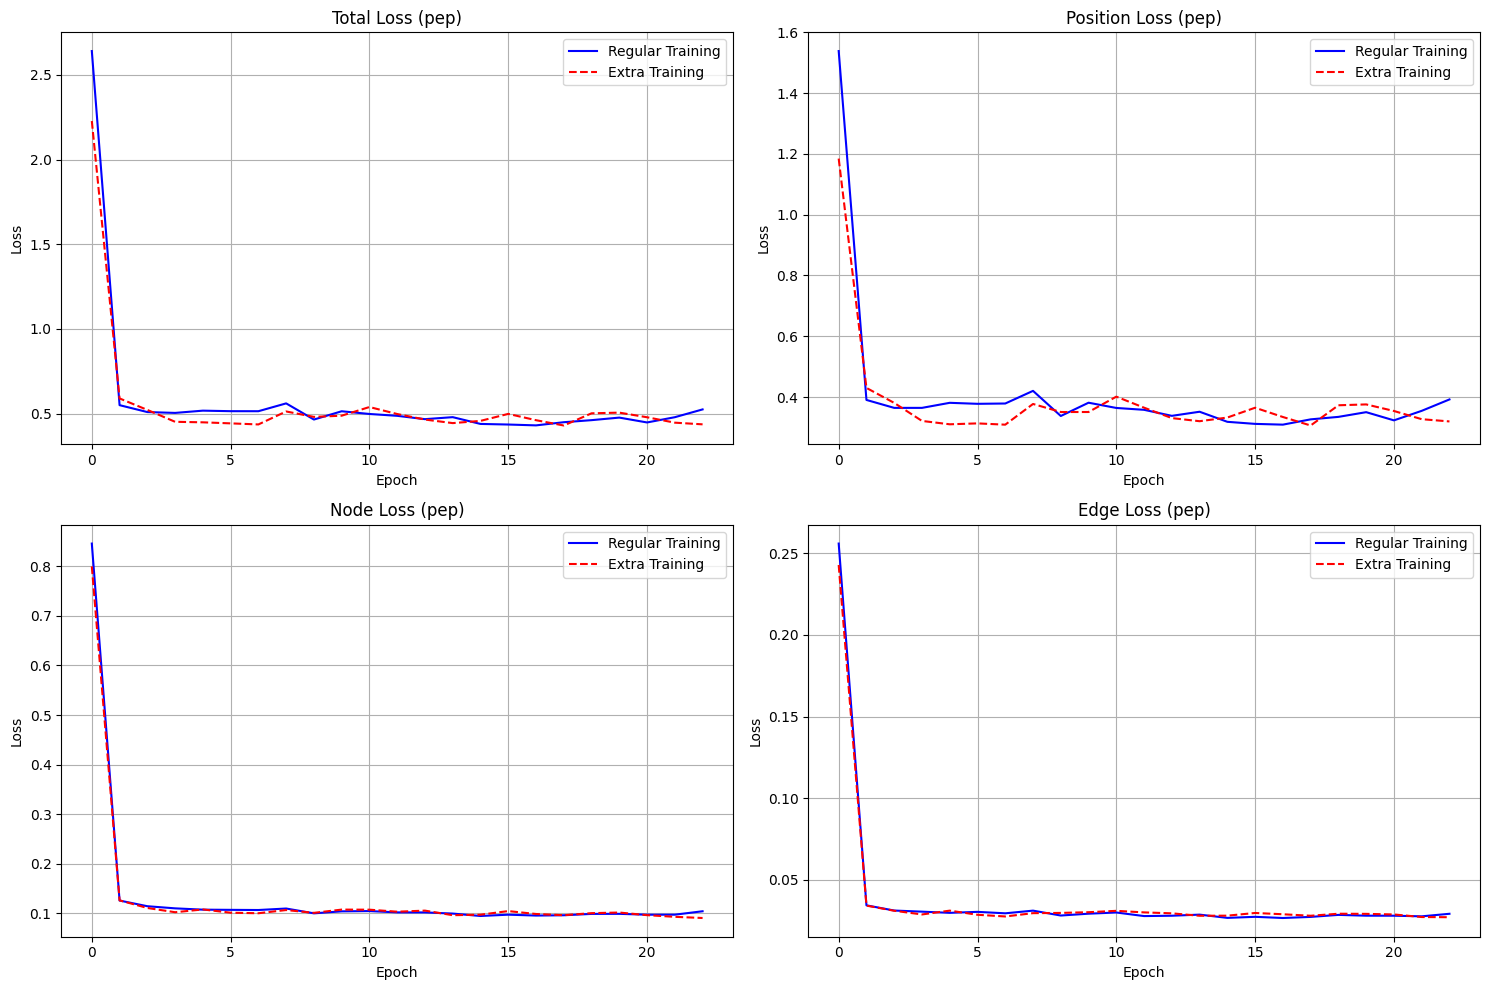

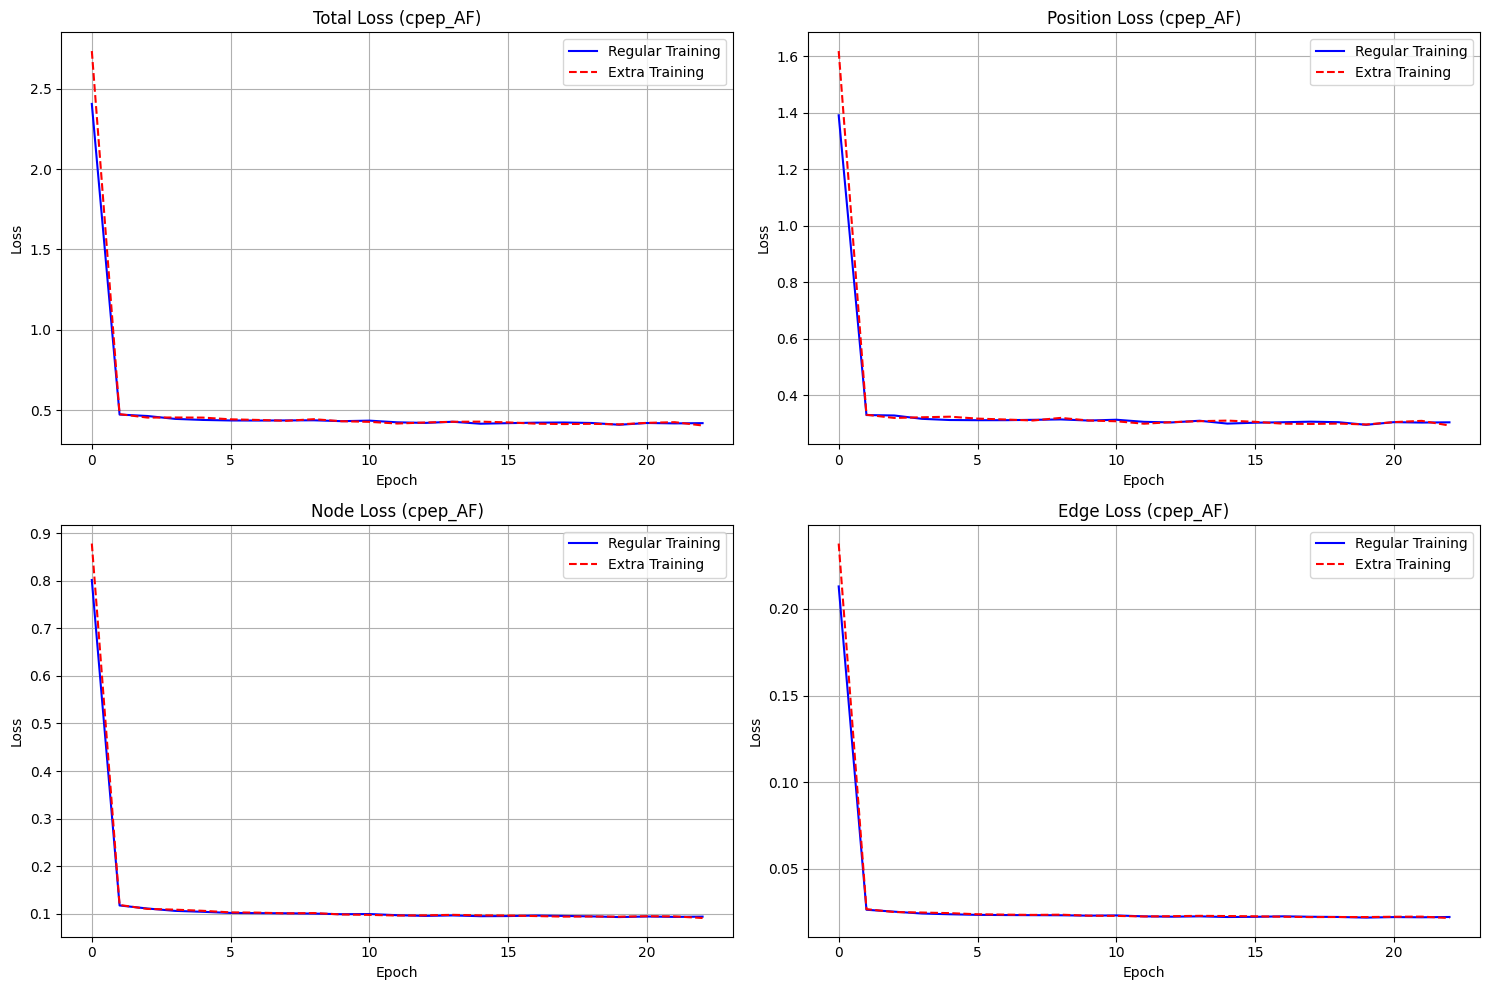

In [9]:
for category in categories:
    plt.figure(figsize=(15, 10))
    cat_data = grouped[grouped['category'] == category]
    
    # Separate regular and extra training
    regular = cat_data[cat_data['is_extra_training'] == False]
    extra = cat_data[cat_data['is_extra_training'] == True]
    
    # Plot each loss type
    for i, (loss_type, title) in enumerate(zip(loss_types, titles), 1):
        plt.subplot(2, 2, i)
        
        # Plot regular training
        plt.plot(regular['epoch'], regular[loss_type], 'b-', label='Regular Training')
        
        # Plot extra training if exists
        if not extra.empty:
            plt.plot(extra['epoch'], extra[loss_type], 'r--', label='Extra Training')
        
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{title} ({category})')
        plt.grid(True)
        plt.legend()
    
    plt.tight_layout()
    plt.savefig(f'loss_plots_{category}.png')
    plt.show()

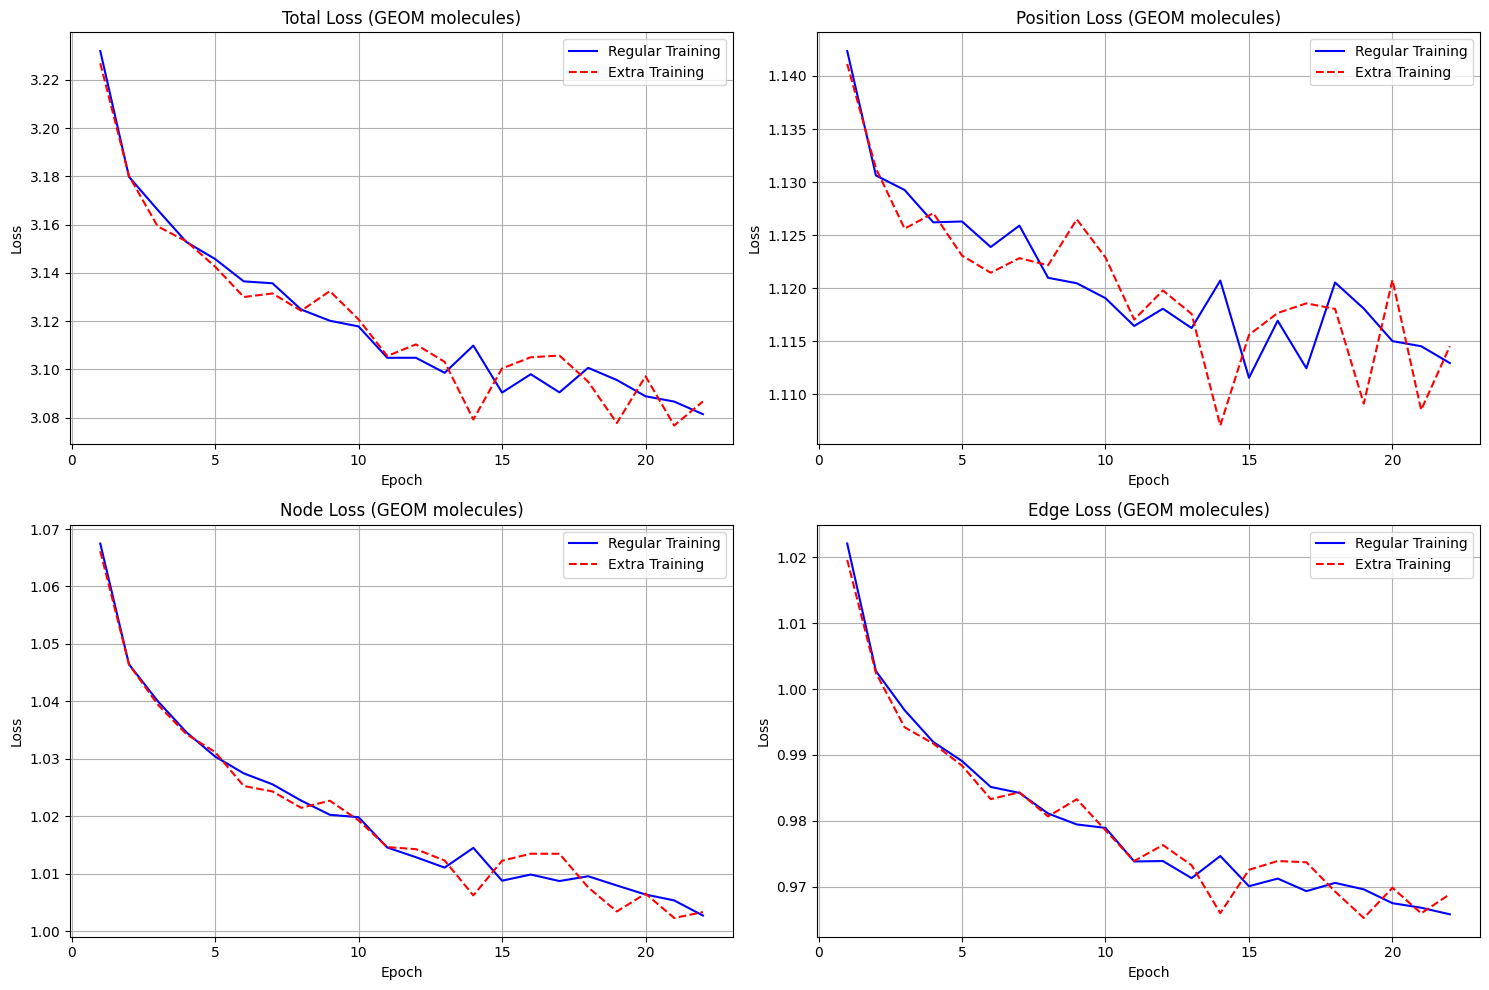

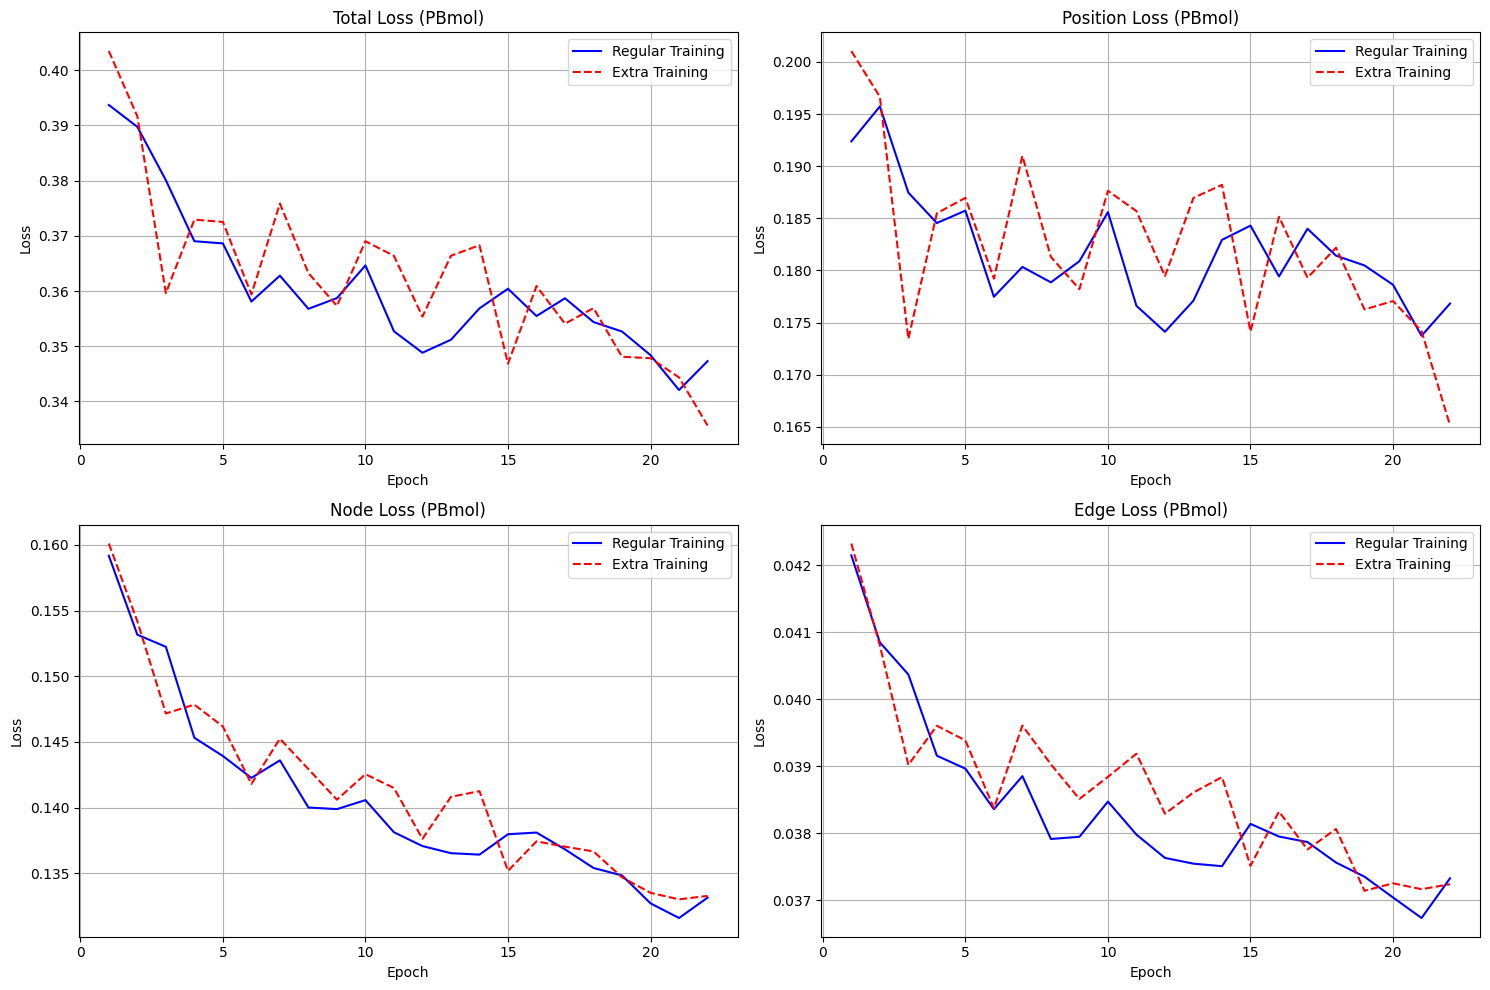

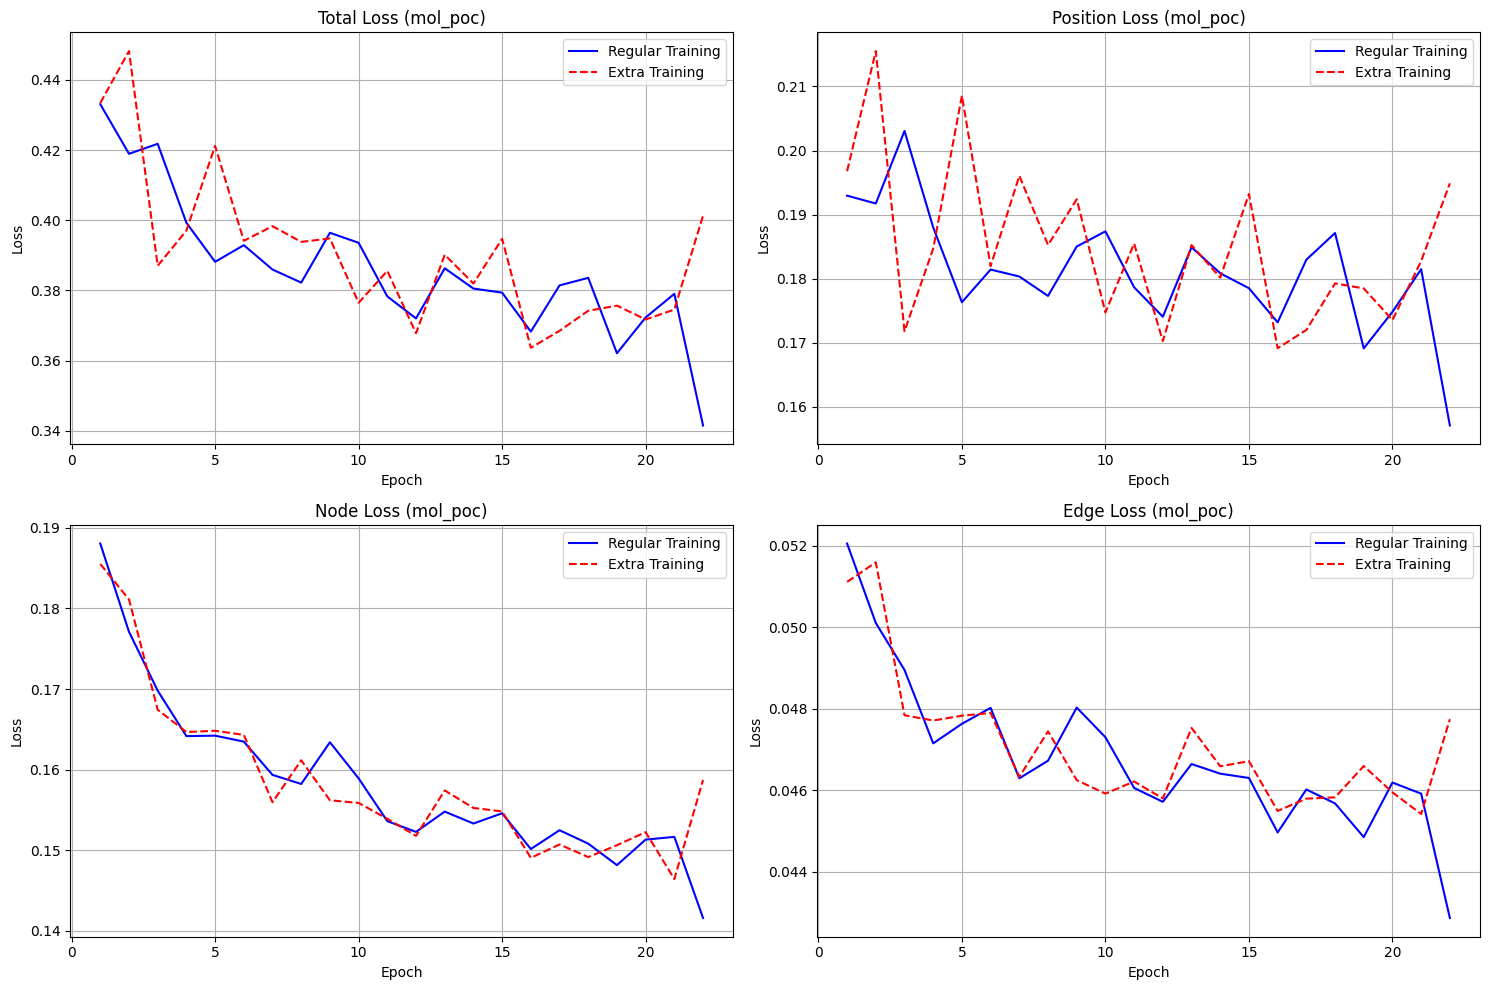

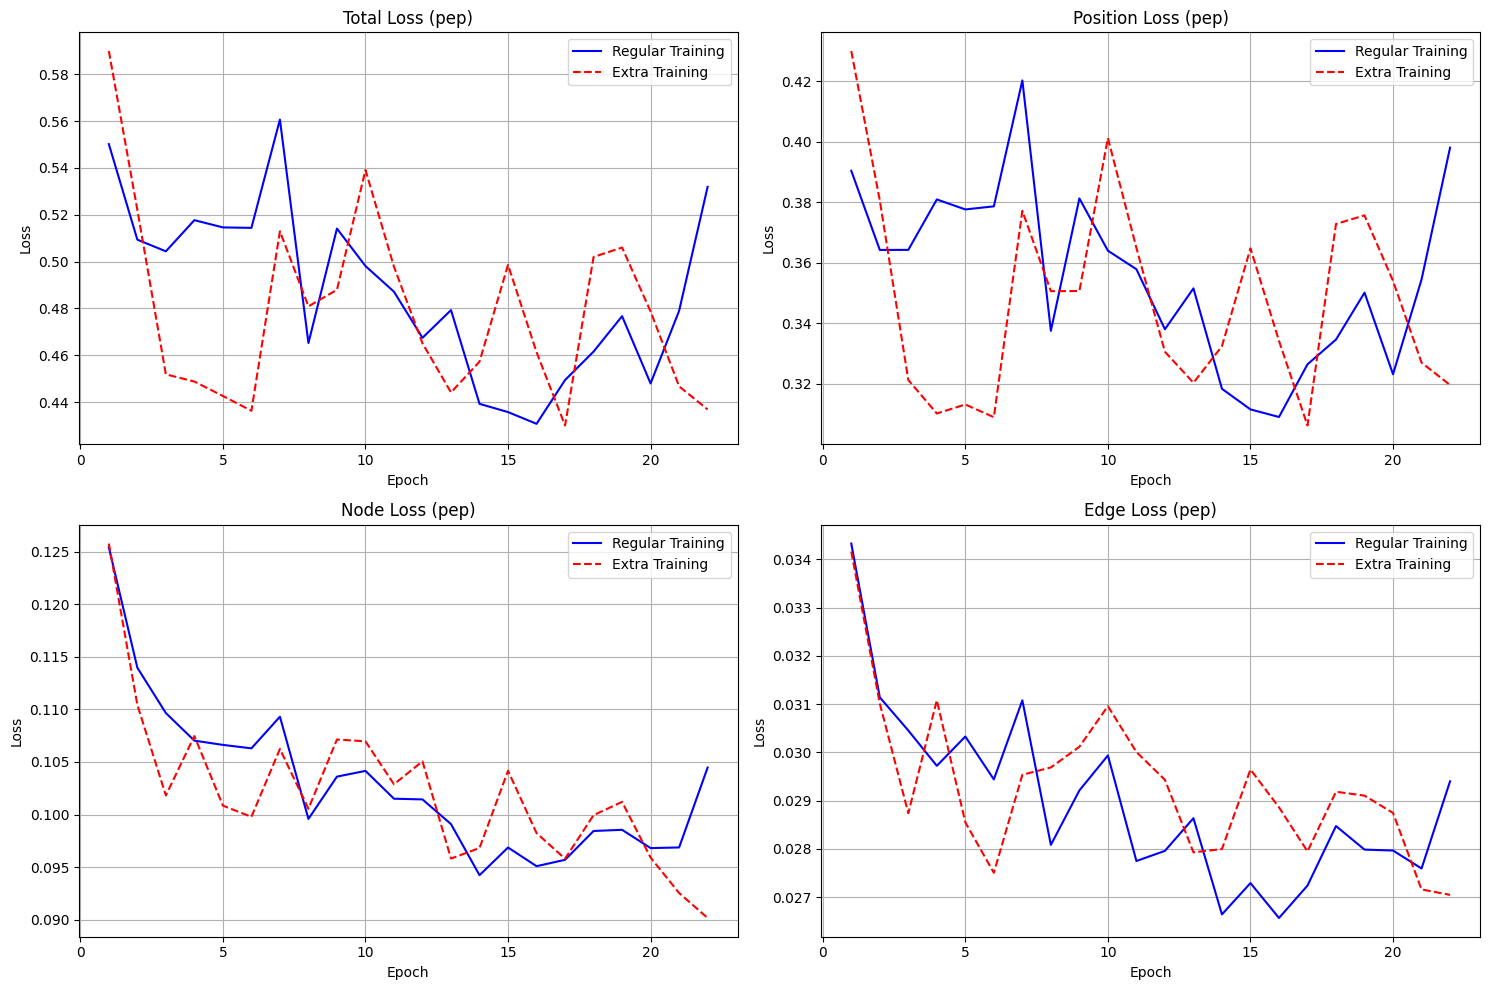

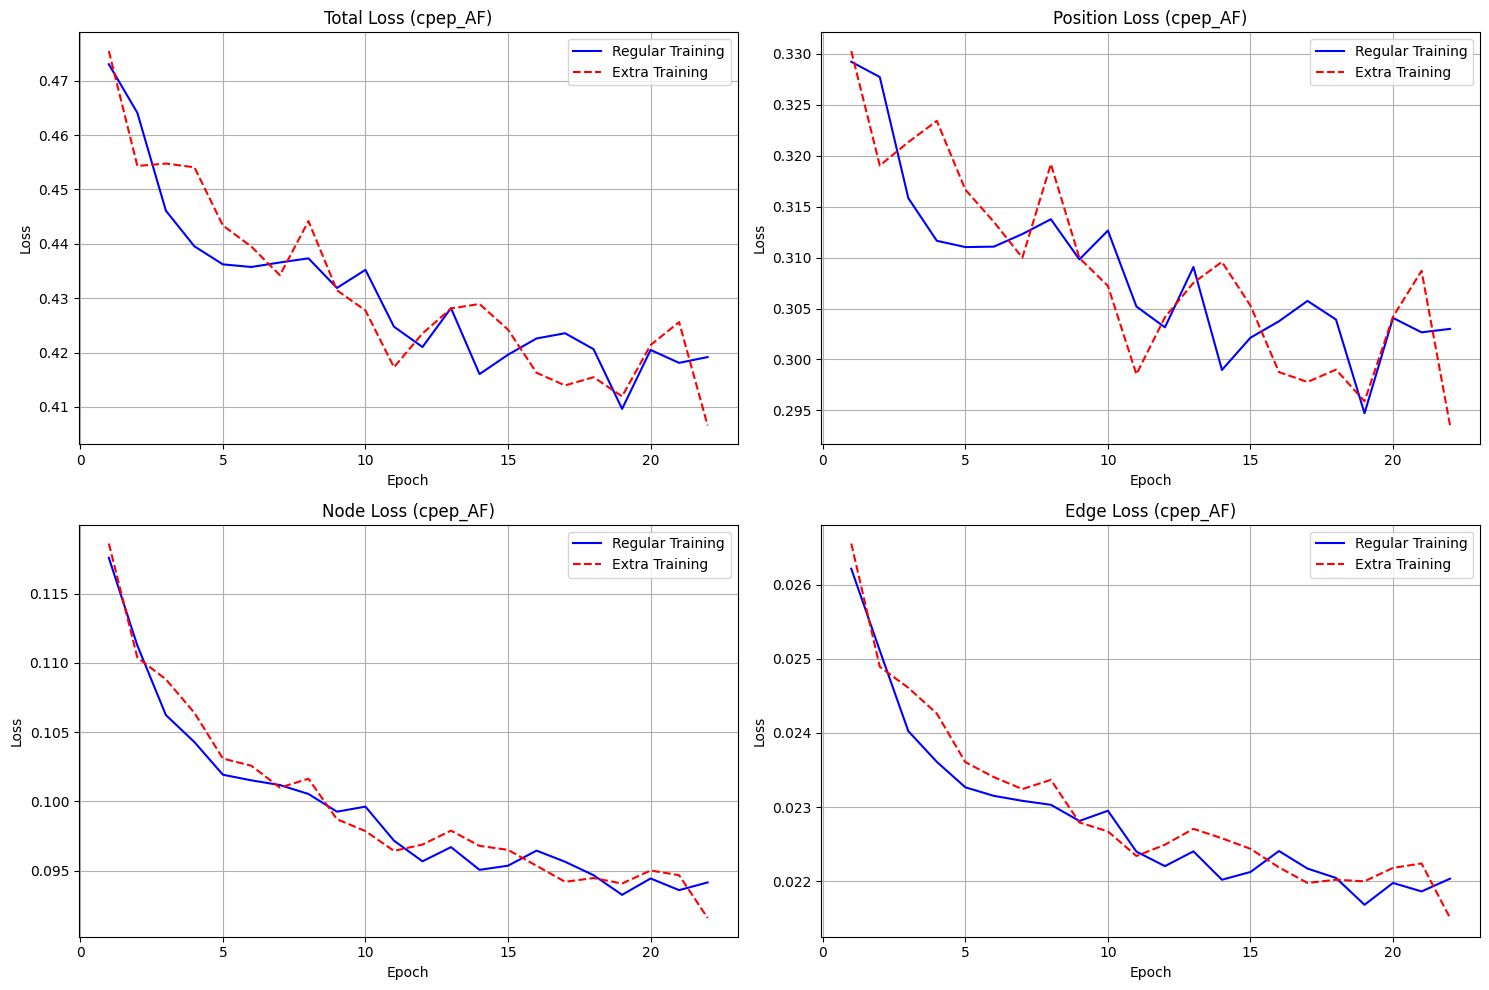

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('/home/chengxi/data/work/test/comp2404/PMT/PMT_250421/peptide2mol/logs_retrain/train_Moldiff_test/runs/2025-04-29_03-57-20/cases_losses.txt')

# Categorize items based on name prefixes
def categorize_name(name):
    if name.startswith('PBmol'):
        return 'PBmol'
    elif name.startswith('cpep_AF'):
        return 'cpep_AF'
    elif name.startswith('pep'):
        return 'pep'
    elif name.startswith('mol') and '_poc' in name:
        return 'mol_poc'
    else:
        return 'GEOM molecules'

df['category'] = df['name'].apply(categorize_name)

# Group by epoch, is_extra_training, and category, calculate mean for each loss type
grouped = df.groupby(['epoch', 'is_extra_training', 'category'])[['total_loss', 'loss_pos', 'loss_node', 'loss_edge']].mean().reset_index()

# Exclude epoch 0
grouped = grouped[grouped['epoch'] != 0]

# Create a figure for each category
categories = df['category'].unique()
loss_types = ['total_loss', 'loss_pos', 'loss_node', 'loss_edge']
titles = ['Total Loss', 'Position Loss', 'Node Loss', 'Edge Loss']

for category in categories:
    plt.figure(figsize=(15, 10))
    cat_data = grouped[grouped['category'] == category]
    
    # Separate regular and extra training
    regular = cat_data[cat_data['is_extra_training'] == False]
    extra = cat_data[cat_data['is_extra_training'] == True]
    
    # Plot each loss type
    for i, (loss_type, title) in enumerate(zip(loss_types, titles), 1):
        plt.subplot(2, 2, i)
        
        # Plot regular training
        plt.plot(regular['epoch'], regular[loss_type], 'b-', label='Regular Training')
        
        # Plot extra training if exists
        if not extra.empty:
            plt.plot(extra['epoch'], extra[loss_type], 'r--', label='Extra Training')
        
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{title} ({category})')
        plt.grid(True)
        plt.legend()
    
    plt.tight_layout()
    plt.savefig(f'loss_plots_{category}_excl_epoch0.png')
    plt.show()

/tmp/ipykernel_2994611/2348555551.py:37: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(data=data, x='Category', y='Loss_Value', hue='Training', palette=palette)
/tmp/ipykernel_2994611/2348555551.py:37: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(data=data, x='Category', y='Loss_Value', hue='Training', palette=palette)
/tmp/ipykernel_2994611/2348555551.py:37: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(data=data, x='Category', y='Loss_Value', hue='Training', palette=palette)
/tmp/ipykernel_2994611/2348555551.py:37: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(data=data, x='Category', y='Loss_Value', hue='Training', palette=palette)


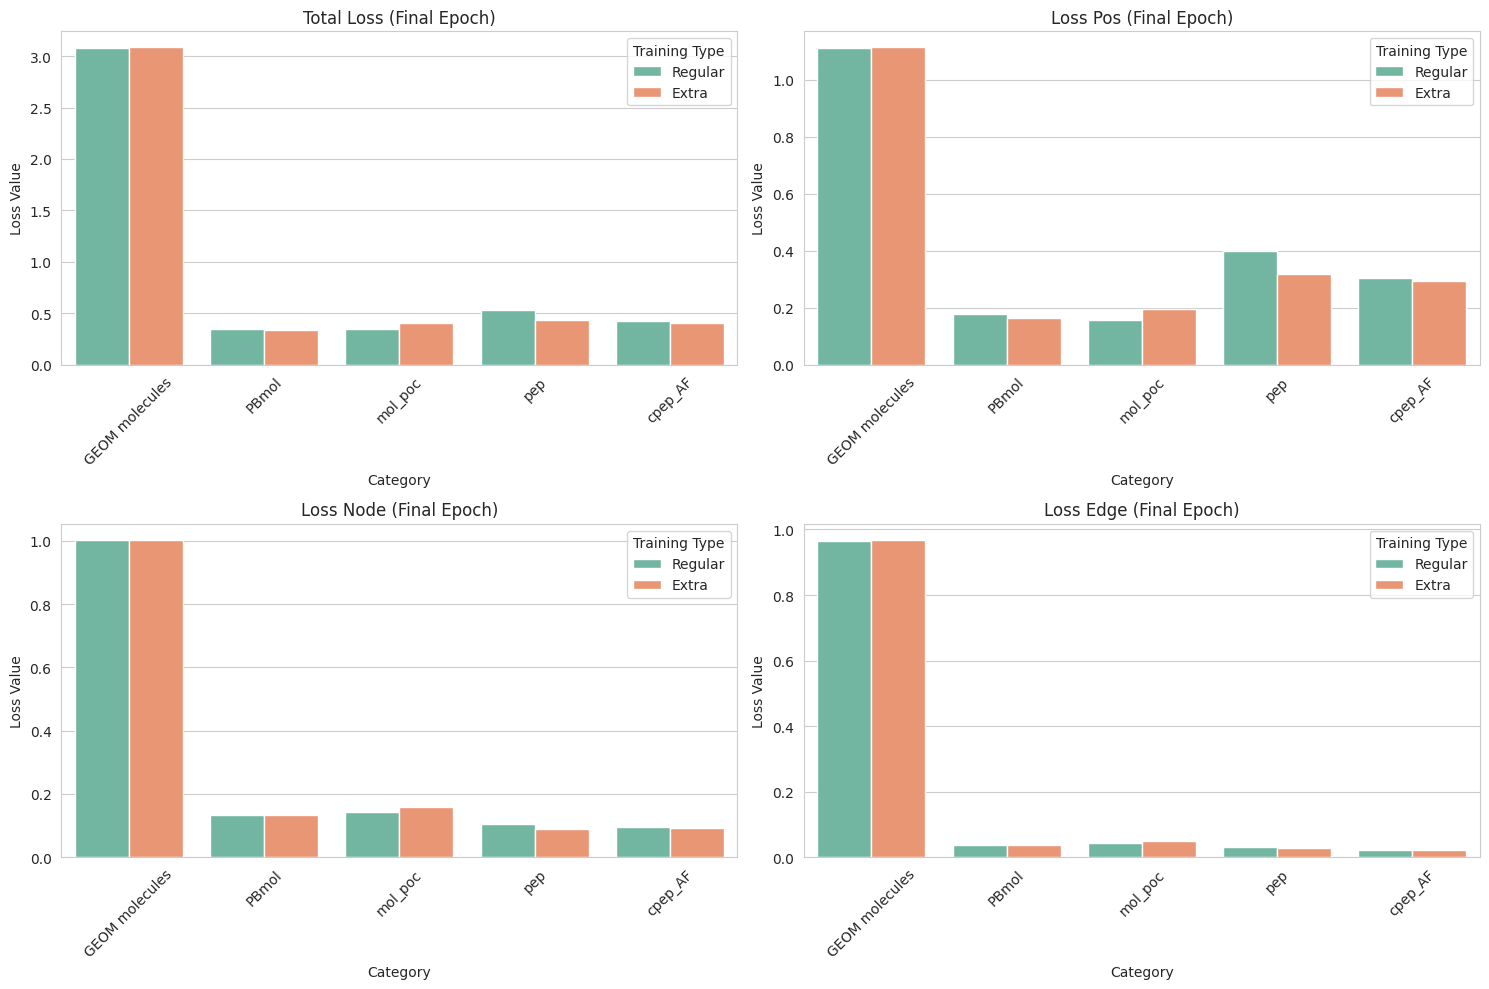

In [14]:
import seaborn as sns
grouped = grouped[grouped['epoch'] != 0]

# Get final epoch data for each category and training type
final_data = []
categories = df['category'].unique()
loss_types = ['total_loss', 'loss_pos', 'loss_node', 'loss_edge']

for category in categories:
    cat_data = grouped[grouped['category'] == category]
    for is_extra in [False, True]:
        training_type = 'Extra' if is_extra else 'Regular'
        cat_train_data = cat_data[cat_data['is_extra_training'] == is_extra]
        if not cat_train_data.empty:
            final_epoch = cat_train_data['epoch'].max()
            final_row = cat_train_data[cat_train_data['epoch'] == final_epoch].iloc[0]
            for loss_type in loss_types:
                final_data.append({
                    'Category': category,
                    'Training': training_type,
                    'Loss_Type': loss_type,
                    'Loss_Value': final_row[loss_type]
                })

final_df = pd.DataFrame(final_data)

# Create a figure with subplots for each loss type
plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")
palette = sns.color_palette("Set2")

# Plot barplots for each loss type
for i, loss_type in enumerate(loss_types, 1):
    plt.subplot(2, 2, i)
    data = final_df[final_df['Loss_Type'] == loss_type]
    
    sns.barplot(data=data, x='Category', y='Loss_Value', hue='Training', palette=palette)
    
    plt.xlabel('Category')
    plt.ylabel('Loss Value')
    plt.title(f'{loss_type.replace("_", " ").title()} (Final Epoch)')
    plt.xticks(rotation=45)
    plt.legend(title='Training Type')
    
plt.tight_layout()
plt.savefig('final_losses_barplot.png')

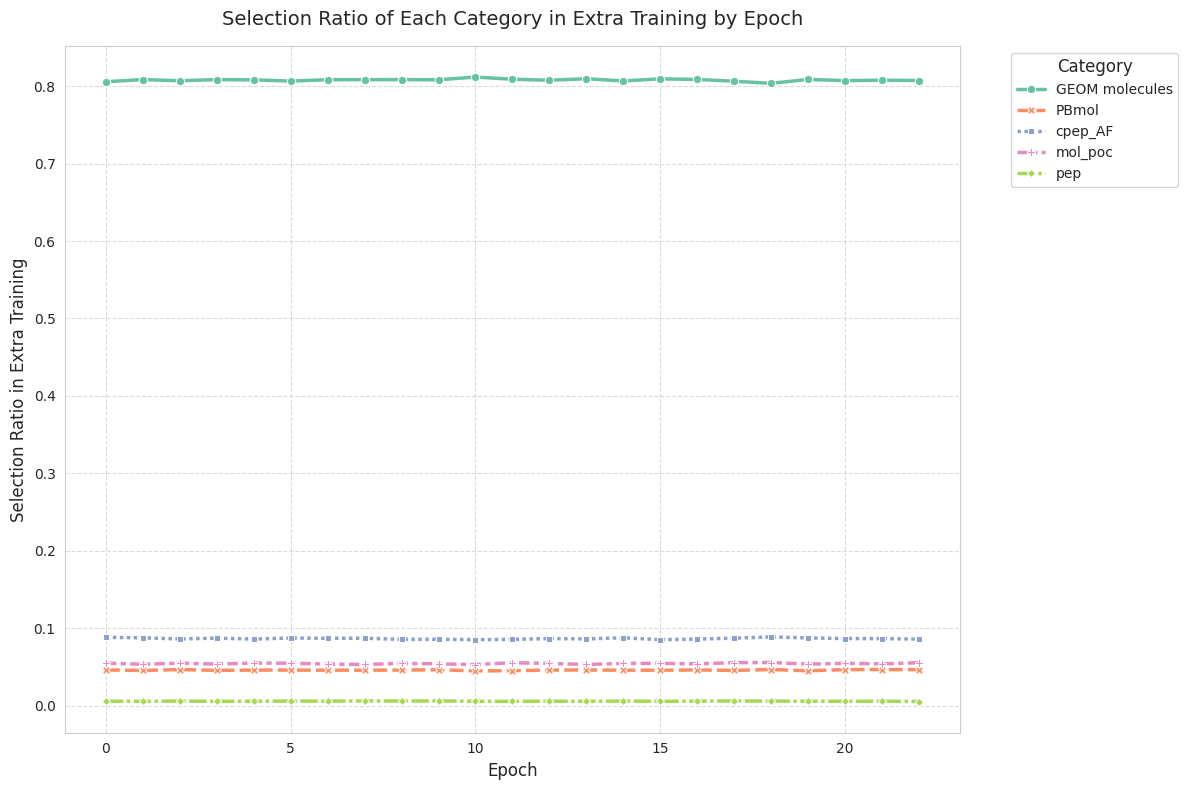

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Filter for extra training data
extra_train = df[df['is_extra_training'] == True]

# Group by epoch and category, count occurrences
counts = extra_train.groupby(['epoch', 'category']).size().reset_index(name='count')

# Calculate total count per epoch
total_per_epoch = extra_train.groupby('epoch').size().reset_index(name='total')

# Merge to calculate proportions
proportions = counts.merge(total_per_epoch, on='epoch')
proportions['ratio'] = proportions['count'] / proportions['total']

# Create the plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
palette = sns.color_palette("Set2", n_colors=len(proportions['category'].unique()))

# Plot lineplot for each category
sns.lineplot(data=proportions, x='epoch', y='ratio', hue='category', 
             style='category', markers=True, palette=palette, linewidth=2.5)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Selection Ratio in Extra Training', fontsize=12)
plt.title('Selection Ratio of Each Category in Extra Training by Epoch', fontsize=14, pad=15)
plt.legend(title='Category', title_fontsize=12, fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('extra_train_selection_ratio.png', bbox_inches='tight')

In [16]:
category_counts = df['category'].value_counts()

# Calculate total number of entries
total_entries = len(df)

# Calculate and print proportions
print("Proportion of each category in all training:")
for category, count in category_counts.items():
    proportion = count / total_entries
    print(f"{category}: {proportion:.4f}")

Proportion of each category in all training:
GEOM molecules: 0.8039
cpep_AF: 0.0900
mol_poc: 0.0543
PBmol: 0.0459
pep: 0.0058
